# Multiple Linear Regression - Toyota Corolla Dataset

Objective : To perform Multiple Linear Regression on Toyota Corolla dataset and understand factors affecting car price.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_error

In [20]:
#loading the dataset
df = pd.read_csv('ToyotaCorolla - MLR.csv')
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


## 1. EXPLORATORY DATA ANALYSIS (EDA)

In [21]:
print("\n--- Summary Statistics ---")
print(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Summary Statistics ---
              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc        Doors  Cylinders        Gears      Weight  
count   1436.00000  1436.000000     1436.0  1436.000000  1436.00000  
mean    1576.85585     4.033426        4.0     5.026462  1072.45961  
std      424.38677     0.952677        0.0     0.188510    52.64112 

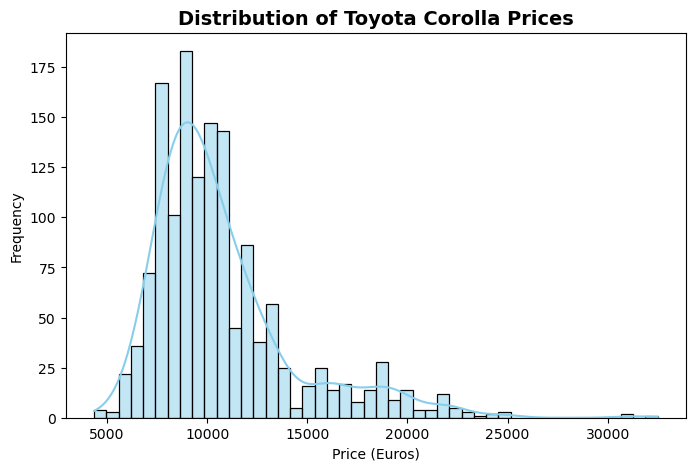

In [24]:
# Visualizing target distribution (Price)
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], kde=True, color='skyblue')
plt.title('Distribution of Toyota Corolla Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price (Euros)')
plt.ylabel('Frequency')
plt.show()

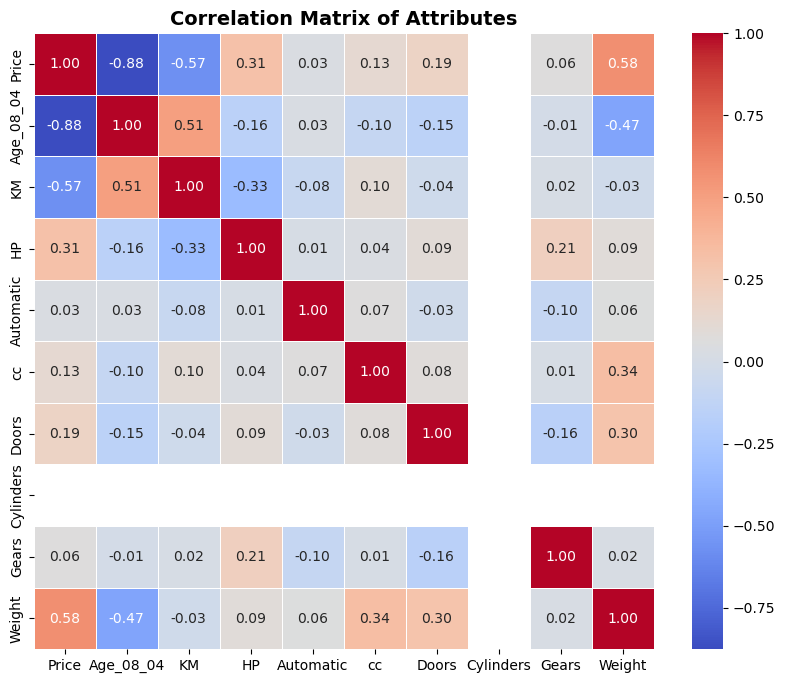

In [26]:
# Visualizing correlations to check for potential multicollinearity
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Attributes', fontsize=14, fontweight='bold')
plt.show()

## 2. DATA SPLITTING & PREPROCESSING

In [32]:
# Define Features (X) and Target Variable (y)
X = df.drop(columns=['Price']).select_dtypes(include=[np.number])
y = df['Price']

# Split dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing features (Essential for Lasso/Ridge regularization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. BUILD MULTIPLE LINEAR REGRESSION (MLR)

In [37]:
mlr_model = LinearRegression()
mlr_model.fit(X_train_scaled, y_train)

# Interpret coefficients
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n--- MLR Coefficients (Standardized) ---")
print(coefficients_df)



--- MLR Coefficients (Standardized) ---
     Feature   Coefficient
8     Weight  1.009459e+03
2         HP  4.070558e+02
7      Gears  1.241711e+02
3  Automatic  8.579207e+01
5      Doors  7.180232e+00
6  Cylinders  1.080025e-12
4         cc -5.292899e+01
1         KM -7.531503e+02
0  Age_08_04 -2.266407e+03


## 4. BUILD LASSO & RIDGE MODELS

In [34]:
# Regularization strengths (alphas) can be adjusted
lasso_model = Lasso(alpha=10.0, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

,alpha,10.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


## 5. MODEL EVALUATION & COMPARISON

In [38]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

models = {
    'Multiple Linear Regression': mlr_model,
    'Lasso Regression': lasso_model,
    'Ridge Regression': ridge_model
}

results = []

for name, model in models.items():
    # Predict on test set
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    })

# Display evaluation dataframe
results_df = pd.DataFrame(results)
print("\n--- Final Performance Evaluation ---")
print(results_df.to_string(index=False))


--- Final Performance Evaluation ---
                     Model        RMSE        MAE  R2 Score
Multiple Linear Regression 1403.611994 997.002406  0.852345
          Lasso Regression 1402.576801 996.018288  0.852563
          Ridge Regression 1404.501181 996.295424  0.852158


## 1. What is Normalization & Standardization and how is it helpful?
Normalization (Min-Max Scaling): Scales data features strictly between a fixed range (usually 0 to 1).
Standardization (Z-score Normalization): Centers data to have a mean of 0 and a standard deviation of 
#Why it is helpful: It prevents features with larger absolute scales (like KM) from dominating features with smaller scales (like Doors).
It is also strictly required for distance-based algorithms and regularized models like Lasso and Ridge to apply penalties fairly.

## 2. What techniques can be used to address multicollinearity in MLR?
Variance Inflation Factor (VIF): Drop features showing a VIF score higher than 5 or 10.
Feature Elimination: Remove highly correlated independent variables detected via the EDA correlation matrix heatmap.
Regularization Techniques: Use Ridge Regression (L2) or Lasso Regression (L1), which natively penalize or zero-out redundant correlated features.
If you'd like, let me know:
The exact column names in your dataset CSV file if they differ from the prompt
If you need help calculating VIF values for your multicollinearity analysis

